# Transformer TST dla danych EnglandWeather

## Biblioteki:

In [2]:
from transformers import  TrainingArguments, Trainer, TimeSeriesTransformerForPrediction,TimeSeriesTransformerConfig
import gdown
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Przygotowanie danych:

In [3]:
file_id = 'EnglandWeather.csv'
url_pogoda = 'https://drive.google.com/file/d/1eBrZ3r3I_7Jn_nMSuAd1tPZrIHMfNEXB/view?usp=sharing'

gdown.download(url_pogoda, file_id, quiet=False, fuzzy=True)
data_weather = pd.read_csv("EnglandWeather.csv")
data_weather['Formatted Date'] = pd.to_datetime(data_weather['Formatted Date'], format='mixed', utc = True).dt.tz_localize(None)
data_weather = data_weather.sort_values('Formatted Date')
data_weather = data_weather.set_index('Formatted Date')
data_weather = data_weather[~data_weather.index.duplicated(keep='first')]
ts_weather = data_weather[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']].resample('h').mean()
ts_weather = ts_weather.interpolate(method='linear')
ts_weather = ts_weather[['Temperature (C)']].copy()
ts_weather.columns = ['Temp']

## zmieniony zbior testowy i treningowy
train_weather = ts_weather[:'2016-06-30'].copy()  
test_weather  = ts_weather['2016-07-01':].copy()

train_weather.head()
test_weather.head()

scaler = StandardScaler()
train_scaled=scaler.fit_transform(train_weather[['Temp']])
test_scaled=scaler.transform(test_weather[['Temp']])

train_array = train_scaled.flatten()
test_array = test_scaled.flatten()

con_length = 168
pred_length = 24

Downloading...
From: https://drive.google.com/uc?id=1eBrZ3r3I_7Jn_nMSuAd1tPZrIHMfNEXB
To: /Users/olgaforiasz/Documents/Sieci neuronowe/Projekt 1/EnglandWeather.csv
100%|██████████| 7.58M/7.58M [00:00<00:00, 29.7MB/s]


## Okna czasowe i obiekty:

In [4]:
class TST_Weather_Dataset(Dataset):
    def __init__(self, data_a, df, con_length, pred_length):
        self.data = data_a
        self.dates = df.index
        self.full_length = con_length      
        self.con_length = con_length - 48  
        self.pred_length = pred_length
        self.history = con_length

    def __len__(self):
        return len(self.data) - self.history - self.pred_length + 1

    def __getitem__(self, index):
        past_values   = self.data[index : index + self.full_length]
        future_values = self.data[index + self.full_length : index + self.full_length + self.pred_length]
        past_dates   = self.dates[index : index + self.full_length]
        future_dates = self.dates[index + self.full_length : index + self.full_length + self.pred_length]

        def get_features(dates):
            dow = (dates.dayofweek.values / 6.0) - 0.5
            month = (dates.month.values - 1) / 11.0 - 0.5
            hour= dates.hour.values / 23.0 - 0.5
            doy = (dates.dayofyear.values - 1) / 365.0 - 0.5 
            return np.stack([hour, dow, month, doy], axis=-1)

        return {
            "past_values":torch.tensor(past_values, dtype=torch.float32),
            "future_values":torch.tensor(future_values, dtype=torch.float32),
            "past_observed_mask":torch.ones(self.full_length, dtype=torch.float32),
            "past_time_features":torch.tensor(get_features(past_dates), dtype=torch.float32), 
            "future_time_features":torch.tensor(get_features(future_dates), dtype=torch.float32), 
        }

train_dataset_tst = TST_Weather_Dataset(
    train_array, 
    train_weather, 
    con_length + 48, 
    pred_length)

test_dataset_tst  = TST_Weather_Dataset(
    test_array,  
    test_weather,  
    con_length + 48, 
    pred_length)


## Stworzenie i trenowanie modelu TST:

In [6]:
config = TimeSeriesTransformerConfig(
    prediction_length=pred_length,
    context_length=con_length,
    input_size=1,
    num_time_features=4,
    d_model=128,
    encoder_layers=4,
    decoder_layers=4,
    dropout=0.1,
    lags_sequence = [1, 2, 3, 24, 48],
    num_parallel_samples=100
)

model_tst = TimeSeriesTransformerForPrediction(config)

training_args = TrainingArguments(
    output_dir="./tst_weather",
    num_train_epochs=20, 
    learning_rate=1e-4,
    per_device_train_batch_size=64,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    label_names=["future_values"]
)

trainer = Trainer(
    model=model_tst,
    args=training_args,
    train_dataset=train_dataset_tst,
    eval_dataset=test_dataset_tst
)

trainer.train()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,-0.105752,-0.828642
2,-0.538778,-1.021952
3,-0.660599,-1.110612
4,-0.718582,-1.185098
5,-0.752383,-1.213050
6,-0.777337,-1.213589
7,-0.803467,-1.218235
8,-0.820377,-1.250586
9,-0.838278,-1.223673
10,-0.853155,-1.288978


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't 

TrainOutput(global_step=28700, training_loss=-0.79058784351947, metrics={'train_runtime': 7741.7272, 'train_samples_per_second': 237.1, 'train_steps_per_second': 3.707, 'total_flos': 2065412846747520.0, 'train_loss': -0.79058784351947, 'epoch': 20.0})

## Prognozowanie za pomocą modelu TST:

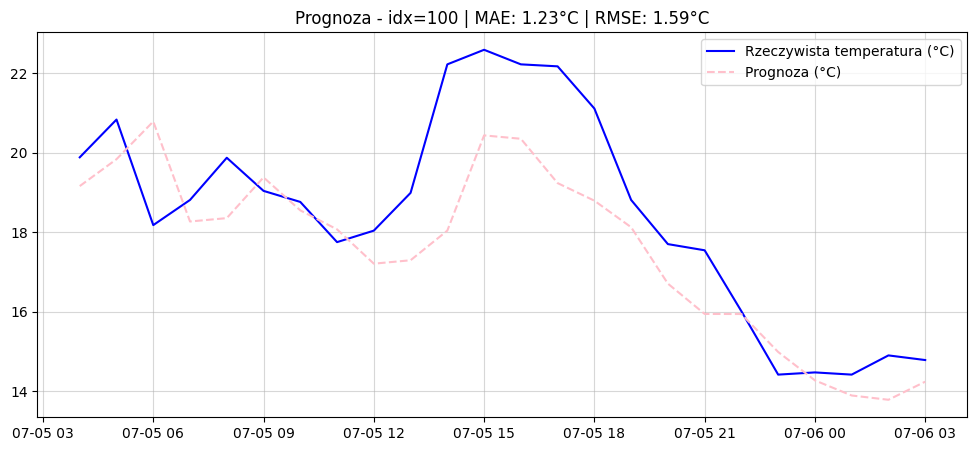

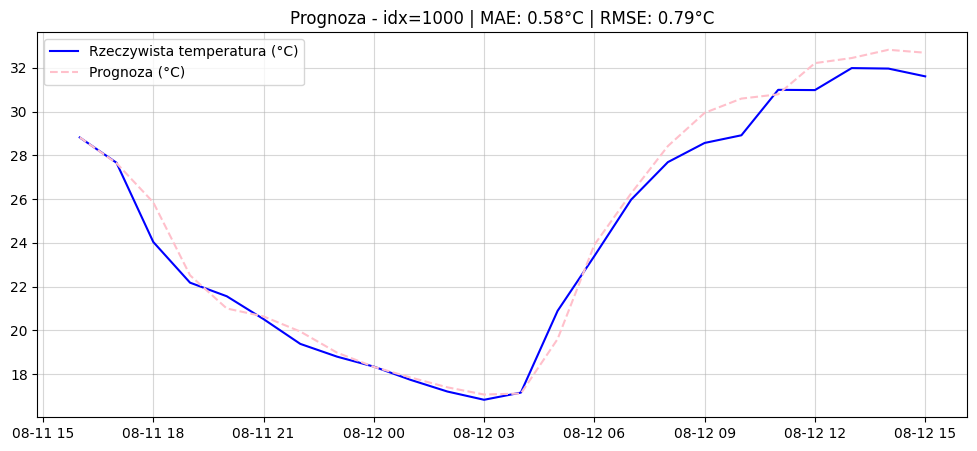

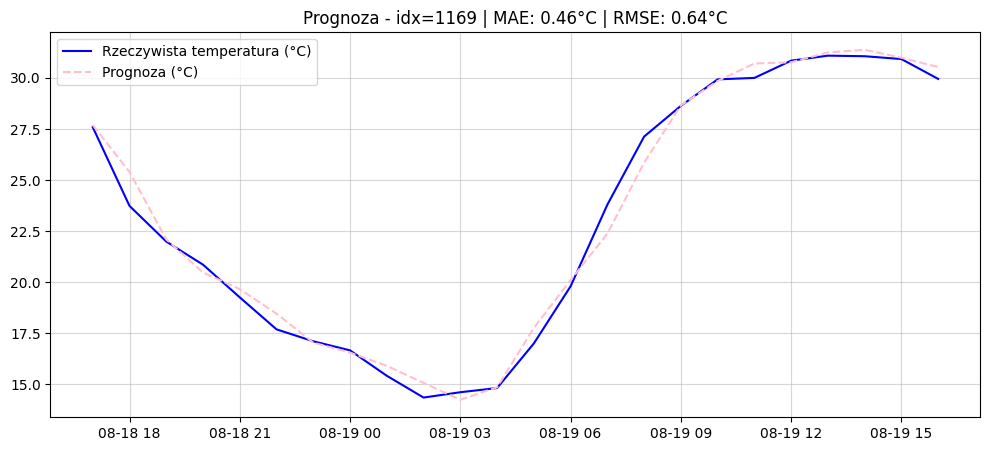

In [ ]:
test_results = trainer.predict(test_dataset_tst)
samples = np.array(test_results.predictions[0])
pred_model_scale = np.median(samples, axis=0)

for nazwa, idx in [('idx=100', 100), ('idx=1000', 1000), ('idx=1169', 1169)]:
    pred_seq = pred_model_scale[idx, :]
    act_seq= test_dataset_tst[idx]['future_values'].numpy().flatten()
    pred_temp= scaler.inverse_transform(pred_seq.reshape(-1, 1)).flatten()
    act_temp = scaler.inverse_transform(act_seq.reshape(-1, 1)).flatten()
    dates = test_weather.index[idx : idx + pred_length]
    mae = mean_absolute_error(act_temp, pred_temp)
    rmse = np.sqrt(mean_squared_error(act_temp, pred_temp))
    plt.figure(figsize=(12, 5))
    plt.plot(dates, act_temp,  label="Rzeczywista temperatura (°C)", color='blue')
    plt.plot(dates, pred_temp, label="Prognoza (°C)", color='pink', linestyle='--')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.title(f"Prognoza - {nazwa} | MAE: {mae:.2f}°C | RMSE: {rmse:.2f}°C")
    plt.show()